# 2/3 — Transformer–KAN RUL Prediction (All 4 Subsets)
**Paper protocol: merge train+test → NASA standard split (train on train_FDxxx, test on test_FDxxx)**
Uses `efficient-kan` library for KAN layers.

| Parameter | Value |
|---|---|
| d_model | 32 |
| FFN hidden (KAN) | 64 |
| Heads | 8 |
| Encoder layers | 6 |
| KAN grid | 20 |
| KAN spline order | 3 |
| Dropout | 0.2 |
| LR | 1e-4 |
| Batch | 256 |
| Epochs | 50 |
| RUL cap | 125 |

In [1]:
# ============================================================
# CELL 1: Setup
# ============================================================
import subprocess, sys, os
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "torch>=2.0", "matplotlib>=3.7.0", "numpy>=1.24.3",
    "pandas>=2.0.0", "scikit-learn>=1.3.0"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
    "git+https://github.com/Blealtan/efficient-kan.git"], check=True)

DATASET_DIR = "/content/dataset"
required = [f"{p}_FD00{i}.txt" for p in ["train", "test", "RUL"] for i in range(1, 5)]
missing = [f for f in required if not os.path.exists(os.path.join(DATASET_DIR, f))]
if missing: raise FileNotFoundError(f"❌ Missing: {missing}")

import torch, numpy as np, pandas as pd
from efficient_kan import KANLinear
print(f"✅ PyTorch {torch.__version__} | CUDA: {torch.cuda.is_available()} | efficient-kan loaded")
if torch.cuda.is_available(): print(f"   GPU: {torch.cuda.get_device_name(0)}")

✅ PyTorch 2.10.0+cu128 | CUDA: True | efficient-kan loaded
   GPU: NVIDIA L4


In [2]:
# ============================================================
# CELL 2: Data Pipeline (NASA Standard Split)
# ============================================================
from sklearn.preprocessing import StandardScaler
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn, math, time, gc
import sklearn.metrics as me
from torch.optim.lr_scheduler import CosineAnnealingLR

WINDOW_SIZE = 30; RUL_CAP = 125; SEED = 42
index_cols = ["engine_id", "cycle"]
setting_cols = [f"setting_{i}" for i in range(1, 4)]
sensor_cols = [f"sensor_{i}" for i in range(1, 22)]
all_cols = index_cols + setting_cols + sensor_cols
DROP_SENSORS = ["sensor_1", "sensor_5", "sensor_6", "sensor_10",
                "sensor_16", "sensor_18", "sensor_19"]
KEEP_SENSORS = [s for s in sensor_cols if s not in DROP_SENSORS]
N_FEATURES = len(KEEP_SENSORS)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"


class CMAPSSWindowDataset(Dataset):
    def __init__(self, df, sensors, window_size):
        self.samples, self.labels, self.engine_ids = [], [], []
        for eid, grp in df.groupby("engine_id"):
            data = grp[sensors].values.astype(np.float32)
            rul = grp["rul_norm"].values.astype(np.float32)
            if len(data) < window_size:
                pad = window_size - len(data)
                data = np.vstack([np.tile(data[0], (pad, 1)), data])
                rul = np.concatenate([np.full(pad, rul[0]), rul])
            for i in range(window_size, len(data) + 1):
                self.samples.append(data[i - window_size:i])
                self.labels.append(rul[i - 1])
                self.engine_ids.append(eid)
        self.samples = np.array(self.samples)
        self.labels = np.array(self.labels)
        self.engine_ids = np.array(self.engine_ids)
    def __len__(self): return len(self.labels)
    def __getitem__(self, idx):
        return (torch.tensor(self.samples[idx]), torch.tensor(self.labels[idx]))


def load_subset_standard(subset):
    """
    Standard NASA C-MAPSS protocol:
      - Train on train_FDxxx.txt (full life cycles)
      - Test on test_FDxxx.txt (truncated) using ground truth from RUL_FDxxx.txt
      - Scaler fit on training data only (no leakage)
      - 80/20 train/val split from training data
    Returns: train_ds, val_ds, test_ds (test = ALL test engines from NASA file)
    """
    train_df = pd.read_csv(os.path.join(DATASET_DIR, f"train_{subset}.txt"),
                           sep=r"\s+", header=None, names=all_cols)
    test_df = pd.read_csv(os.path.join(DATASET_DIR, f"test_{subset}.txt"),
                          sep=r"\s+", header=None, names=all_cols)
    rul_df = pd.read_csv(os.path.join(DATASET_DIR, f"RUL_{subset}.txt"),
                         sep=r"\s+", header=None, names=["rul"])
    rul_df["engine_id"] = rul_df.index + 1

    # Train RUL: full life cycles, RUL = max_cycle - current_cycle
    mx = train_df.groupby("engine_id")["cycle"].max().reset_index()
    mx.columns = ["engine_id", "max_cycle"]
    train_df = train_df.merge(mx, on="engine_id", how="left")
    train_df["rul"] = (train_df["max_cycle"] - train_df["cycle"]).clip(upper=RUL_CAP)
    train_df.drop("max_cycle", axis=1, inplace=True)

    # Test RUL: extrapolate backward from ground truth at last cycle
    mx_t = test_df.groupby("engine_id")["cycle"].max().reset_index()
    mx_t.columns = ["engine_id", "max_cycle"]
    test_df = test_df.merge(mx_t, on="engine_id", how="left")
    test_df = test_df.merge(rul_df, on="engine_id", how="left")
    test_df["rul"] = (test_df["rul"] + test_df["max_cycle"] - test_df["cycle"]).clip(upper=RUL_CAP)
    test_df.drop("max_cycle", axis=1, inplace=True)

    # Normalize: fit on training data ONLY (no leakage)
    scaler = StandardScaler()
    train_df[KEEP_SENSORS] = scaler.fit_transform(train_df[KEEP_SENSORS])
    test_df[KEEP_SENSORS] = scaler.transform(test_df[KEEP_SENSORS])
    train_df["rul_norm"] = train_df["rul"] / RUL_CAP
    test_df["rul_norm"] = test_df["rul"] / RUL_CAP

   # 80/20 Engine-level train/val split
    train_engines = train_df["engine_id"].unique()
    rng = np.random.RandomState(SEED)
    rng.shuffle(train_engines)

    n_val_eng = int(len(train_engines) * 0.2)
    val_engines = train_engines[:n_val_eng]
    tr_engines = train_engines[n_val_eng:]

    train_split = train_df[train_df["engine_id"].isin(tr_engines)].copy()
    val_split = train_df[train_df["engine_id"].isin(val_engines)].copy()

    # Build datasets securely
    train_ds = CMAPSSWindowDataset(train_split, KEEP_SENSORS, WINDOW_SIZE)
    val_ds = CMAPSSWindowDataset(val_split, KEEP_SENSORS, WINDOW_SIZE)
    test_ds = CMAPSSWindowDataset(test_df, KEEP_SENSORS, WINDOW_SIZE)

    n_test_eng = test_df["engine_id"].nunique()
    print(f"   Train Eng: {len(tr_engines)} | Val Eng: {len(val_engines)} | Test Eng: {n_test_eng}")
    return train_ds, val_ds, test_ds


print(f"✅ Data pipeline ready ({N_FEATURES} sensors, NASA standard split, no leakage)")


✅ Data pipeline ready (14 sensors, NASA standard split, no leakage)


In [3]:
# ============================================================
# CELL 3: Transformer–KAN Model (efficient-kan)
# ============================================================
from efficient_kan import KANLinear


class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=500, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class KANFeedForward(nn.Module):
    def __init__(self, d_model, d_hidden, grid_size=20, spline_order=3, dropout=0.1):
        super().__init__()
        self.kan1 = KANLinear(d_model, d_hidden, grid_size=grid_size, spline_order=spline_order)
        self.kan2 = KANLinear(d_hidden, d_model, grid_size=grid_size, spline_order=spline_order)
        self.dropout = nn.Dropout(dropout)
    def forward(self, x):
        return self.dropout(self.kan2(self.dropout(self.kan1(x))))


class TransformerKANEncoderLayer(nn.Module):
    def __init__(self, d_model, nhead, dim_ff, dropout=0.1, grid_size=20, spline_order=3):
        super().__init__()
        self.self_attn = nn.MultiheadAttention(d_model, nhead, dropout=dropout, batch_first=True)
        self.kan_ffn = KANFeedForward(d_model, dim_ff, grid_size, spline_order, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    def forward(self, x):
        attn_out, _ = self.self_attn(x, x, x)
        x = self.norm1(x + self.dropout1(attn_out))
        x = self.norm2(x + self.dropout2(self.kan_ffn(x)))
        return x


class TransformerKAN(nn.Module):
    def __init__(self, n_features, d_model=32, nhead=8, num_layers=6,
                 dim_ff=64, dropout=0.2, grid_size=20, spline_order=3):
        super().__init__()
        self.input_proj = nn.Linear(n_features, d_model)
        self.pos_enc = PositionalEncoding(d_model, dropout=dropout)
        self.layers = nn.ModuleList([
            TransformerKANEncoderLayer(d_model, nhead, dim_ff, dropout, grid_size, spline_order)
            for _ in range(num_layers)
        ])
        self.head = nn.Sequential(
            nn.LayerNorm(d_model),
            KANLinear(d_model, 32, grid_size=grid_size, spline_order=spline_order),
            nn.Dropout(dropout),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        x = self.pos_enc(self.input_proj(x))
        for layer in self.layers:
            x = layer(x)
        return self.head(x.mean(dim=1)).squeeze(-1)


print("✅ TransformerKAN defined (efficient-kan, grid=20)")

✅ TransformerKAN defined (efficient-kan, grid=20)


In [4]:
# ============================================================
# CELL 4: Train & Evaluate Functions
# ============================================================

def train_model(model, train_ds, val_ds, save_path,
                epochs=50, batch_size=256, lr=1e-4, patience=15):
    model = model.to(DEVICE)
    tl = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    vl = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    criterion = nn.MSELoss()
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    best_val = float("inf"); wait = 0
    history = {"train_loss": [], "val_loss": []}
    n_train, n_val = len(train_ds), len(val_ds)

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        model.train(); ts = 0.0
        for X, y in tl:
            X, y = X.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(X), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            ts += loss.item() * X.size(0)

        model.eval(); vs = 0.0
        with torch.no_grad():
            for X, y in vl:
                X, y = X.to(DEVICE), y.to(DEVICE)
                vs += criterion(model(X), y).item() * X.size(0)

        tl_val = ts/n_train; vl_val = vs/n_val
        scheduler.step()
        history["train_loss"].append(tl_val); history["val_loss"].append(vl_val)

        if vl_val < best_val:
            best_val = vl_val; wait = 0
            torch.save(model.state_dict(), save_path); m = " ★"
        else: wait += 1; m = ""

        if epoch % 10 == 0 or epoch == 1 or m:
            print(f"    Ep {epoch:3d}/{epochs} train={tl_val:.6f} val={vl_val:.6f} {time.time()-t0:.1f}s{m}")
        if wait >= patience:
            print(f"    ⏹ Early stop at epoch {epoch}"); break

    model.load_state_dict(torch.load(save_path, map_location=DEVICE))
    print(f"    ✅ Best val: {best_val:.6f}")
    return model, history


def nasa_score(yt, yp):
    d = yp - yt
    return np.sum(np.where(d < 0, np.exp(-d/13)-1, np.exp(d/10)-1))


def evaluate_model(model, test_ds, name):
    model.eval()
    loader = DataLoader(test_ds, batch_size=256, shuffle=False, num_workers=2)
    preds, trues = [], []
    with torch.no_grad():
        for X, y in loader:
            preds.append(model(X.to(DEVICE)).cpu().numpy())
            trues.append(y.numpy())
    pc = np.concatenate(preds)*RUL_CAP; tc = np.concatenate(trues)*RUL_CAP
    r2 = me.r2_score(tc, pc)

    df = pd.DataFrame({"eid": test_ds.engine_ids, "true": tc, "pred": pc})
    dl = df.groupby("eid").tail(1)
    ft, fp = dl["true"].values, dl["pred"].values
    rmse = np.sqrt(me.mean_squared_error(ft, fp))
    mae = me.mean_absolute_error(ft, fp)
    mask = ft > 0
    mape = np.mean(np.abs((ft[mask]-fp[mask])/ft[mask]))
    ns = nasa_score(ft, fp)

    print(f"    RMSE:{rmse:.4f} MAE:{mae:.4f} MAPE:{mape:.4f} NASA:{ns:.2f} R²:{r2:.4f} Eng:{len(ft)}")
    df.to_csv(f"/content/tkan_{name}_predictions.csv", index=False)
    dl.to_csv(f"/content/tkan_{name}_lastcycle.csv", index=False)
    return {"Subset": name, "Engines": len(ft), "RMSE": round(rmse,4),
            "MAE": round(mae,4), "MAPE": round(mape,4),
            "NASA_Score": round(ns,4), "R2": round(r2,6)}, dl


print("✅ Functions defined")

✅ Functions defined


In [5]:
# ============================================================
# CELL 5: SWEEP ALL 4 SUBSETS
# ============================================================

SUBSETS = ["FD001", "FD002", "FD003", "FD004"]
all_results = []
all_histories = {}
total_start = time.time()

for subset in SUBSETS:
    print(f"\n{'='*60}")
    print(f"  🚀 TRANSFORMER–KAN — {subset}")
    print(f"{'='*60}")

    train_ds, val_ds, test_ds = load_subset_standard(subset)

    model = TransformerKAN(
        n_features=N_FEATURES, d_model=32, nhead=8,
        num_layers=6, dim_ff=64, dropout=0.2,
        grid_size=20, spline_order=3
    )
    params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"   Params: {params:,}")

    t0 = time.time()
    model, hist = train_model(model, train_ds, val_ds,
        save_path=f"/content/tkan_{subset}.pt",
        epochs=50, batch_size=256, lr=1e-4, patience=15)
    tt = time.time() - t0
    print(f"   Time: {tt:.1f}s ({tt/60:.1f} min)")

    result, _ = evaluate_model(model, test_ds, subset)
    result["Time_s"] = round(tt, 1)
    all_results.append(result)
    all_histories[subset] = hist

    del model, train_ds, val_ds, test_ds
    gc.collect(); torch.cuda.empty_cache()

print(f"\n{'='*60}")
print(f"  ✅ COMPLETE — {(time.time()-total_start)/60:.1f} min total")
print(f"{'='*60}")


  🚀 TRANSFORMER–KAN — FD001
   Train Eng: 80 | Val Eng: 20 | Test Eng: 100
   Params: 666,689
    Ep   1/50 train=0.149902 val=0.027542 14.4s ★
    Ep   2/50 train=0.042769 val=0.025324 13.4s ★
    Ep   3/50 train=0.039184 val=0.023920 13.4s ★
    Ep   4/50 train=0.037436 val=0.022999 13.4s ★
    Ep   5/50 train=0.036036 val=0.022216 13.4s ★
    Ep   6/50 train=0.034721 val=0.021286 13.4s ★
    Ep   7/50 train=0.033630 val=0.020275 13.4s ★
    Ep   8/50 train=0.032003 val=0.019273 13.4s ★
    Ep   9/50 train=0.030856 val=0.018016 13.4s ★
    Ep  10/50 train=0.029912 val=0.016367 13.4s ★
    Ep  11/50 train=0.027539 val=0.014739 13.4s ★
    Ep  13/50 train=0.024929 val=0.013179 13.5s ★
    Ep  14/50 train=0.023936 val=0.011864 13.5s ★
    Ep  17/50 train=0.021836 val=0.011415 13.5s ★
    Ep  18/50 train=0.021105 val=0.011350 13.5s ★
    Ep  19/50 train=0.020885 val=0.011021 13.5s ★
    Ep  20/50 train=0.020440 val=0.011191 13.5s
    Ep  21/50 train=0.020280 val=0.010954 13.5s ★
    Ep 


  TRANSFORMER–KAN — ALL SUBSETS (Paper 70/20/10 split)
Subset  Engines    RMSE     MAE   MAPE   NASA_Score       R2  Time_s
 FD001      100 15.4109 12.0643 0.2139   394.368408 0.752161   679.2
 FD002      259 20.4416 15.7649 0.3247  3119.094727 0.471297  1756.0
 FD003      100 15.3779 10.9500 0.2069   742.560974 0.754562   835.7
 FD004      248 26.3185 20.5186 0.6621 13963.516602 0.455585   983.8
  Paper T-KAN baseline (FD001): RMSE=7.634, MAPE=0.5361


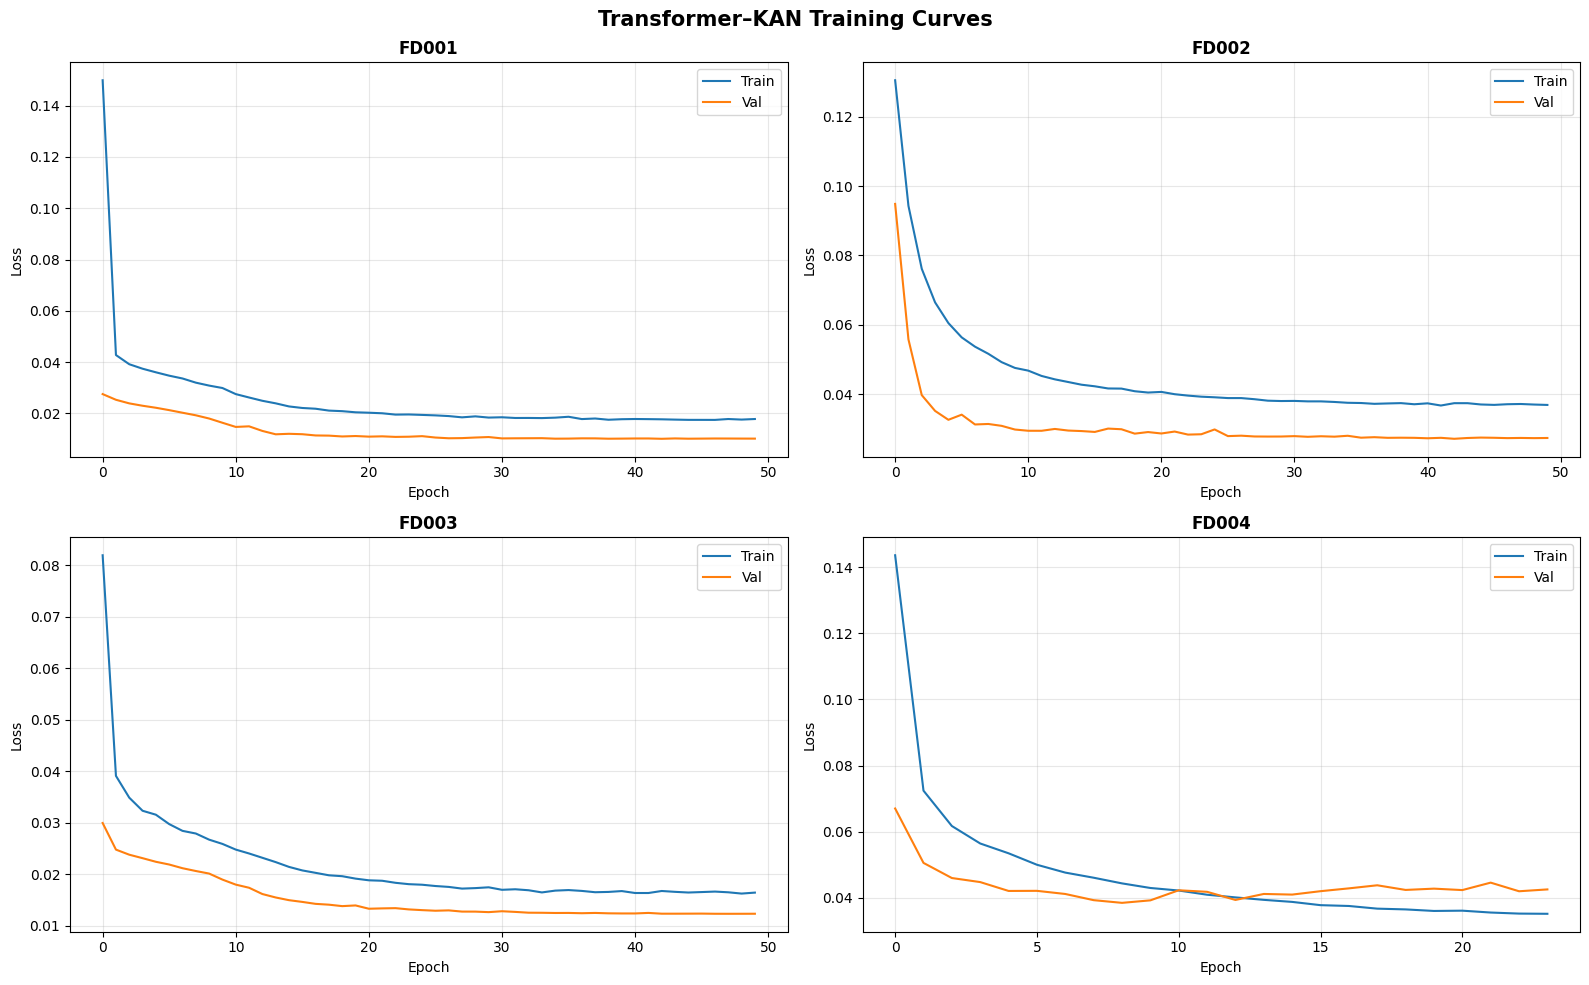

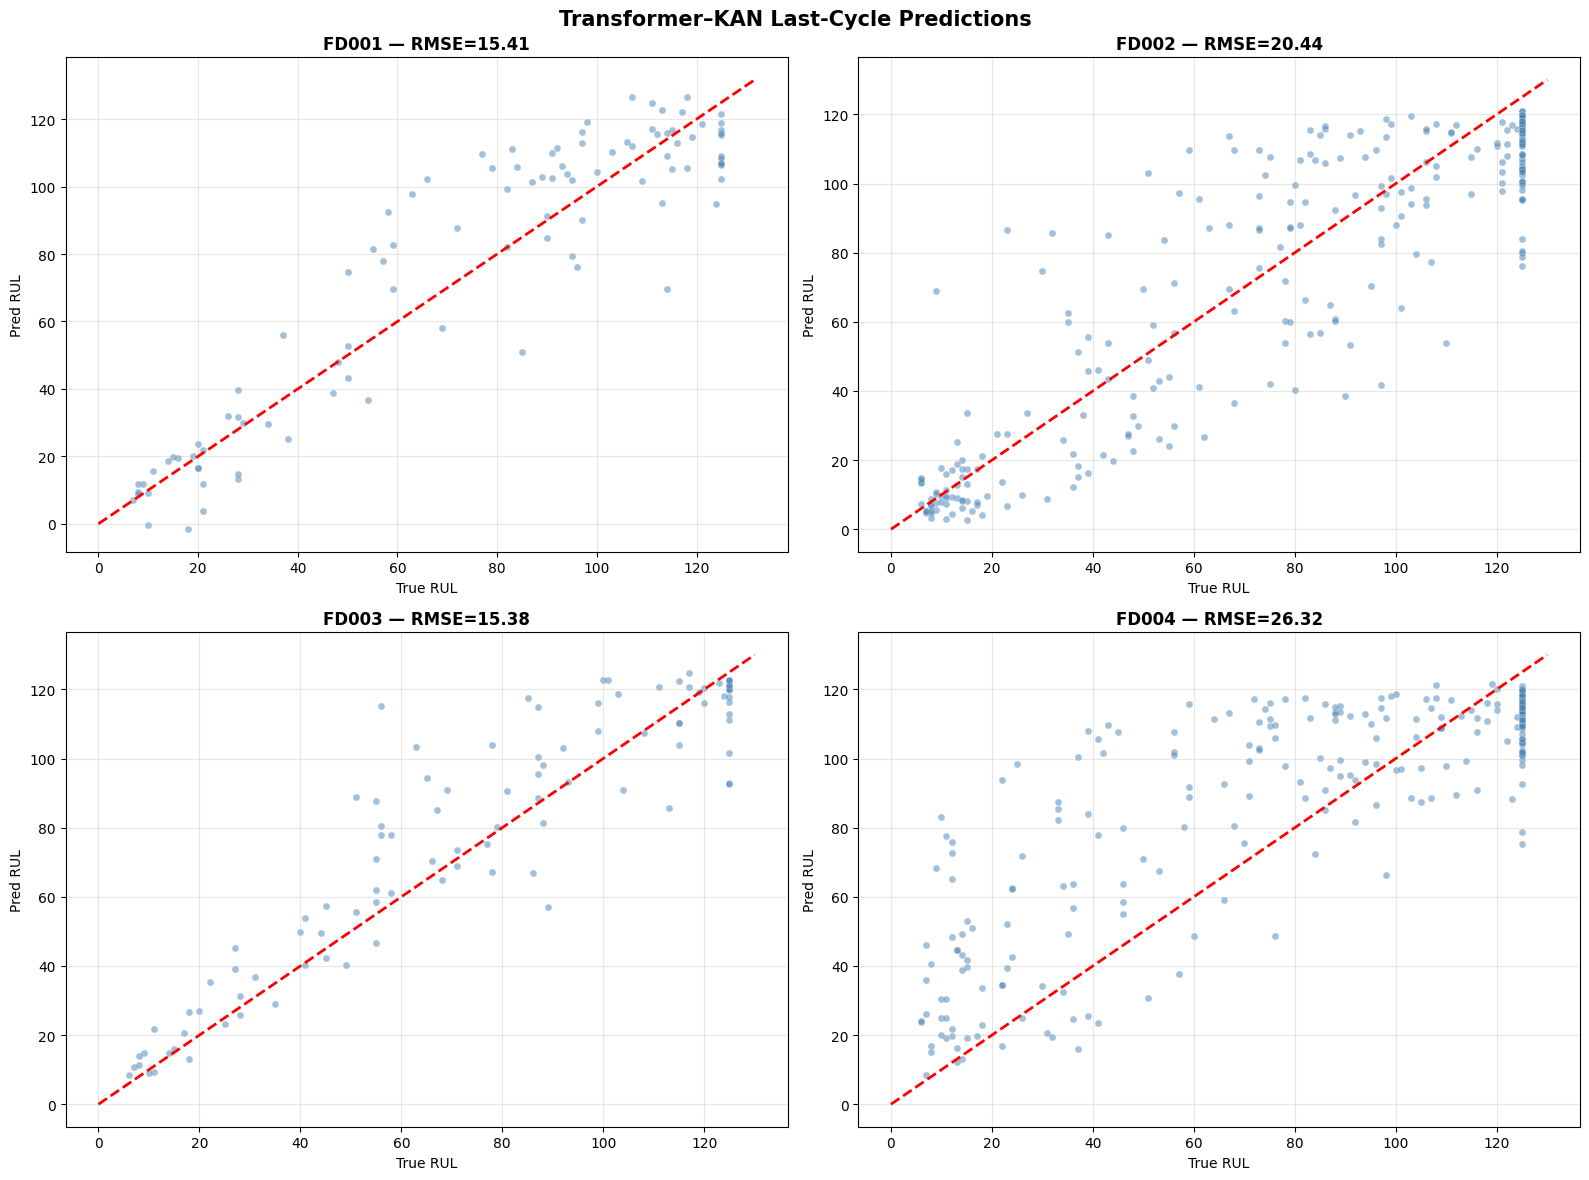

In [6]:
# ============================================================
# CELL 6: Summary & Plots
# ============================================================
import matplotlib.pyplot as plt

df_results = pd.DataFrame(all_results)
print("\n" + "="*70)
print("  TRANSFORMER–KAN — ALL SUBSETS (Paper 70/20/10 split)")
print("="*70)
print(df_results.to_string(index=False))
print("="*70)
print("  Paper T-KAN baseline (FD001): RMSE=7.634, MAPE=0.5361")
df_results.to_csv("/content/tkan_summary.csv", index=False)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
for ax, s in zip(axes.flat, SUBSETS):
    h = all_histories[s]
    ax.plot(h["train_loss"], label="Train"); ax.plot(h["val_loss"], label="Val")
    ax.set_title(s, fontweight="bold"); ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer–KAN Training Curves", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/tkan_loss_curves.png", dpi=150)
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
for ax, s, r in zip(axes.flat, SUBSETS, all_results):
    dl = pd.read_csv(f"/content/tkan_{s}_lastcycle.csv")
    ax.scatter(dl["true"], dl["pred"], alpha=0.5, s=25, c="steelblue", edgecolors="white", linewidth=0.3)
    lim = max(dl["true"].max(), dl["pred"].max()) + 5
    ax.plot([0,lim],[0,lim],"r--",lw=2)
    ax.set_title(f"{s} — RMSE={r['RMSE']:.2f}", fontweight="bold")
    ax.set_xlabel("True RUL"); ax.set_ylabel("Pred RUL"); ax.grid(True, alpha=0.3)
plt.suptitle("Transformer–KAN Last-Cycle Predictions", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("/content/tkan_scatter.png", dpi=150)
plt.show()

In [7]:
# ============================================================
# CELL 7: Download
# ============================================================
try:
    from google.colab import files
    dl = ["/content/tkan_summary.csv",
          "/content/tkan_loss_curves.png",
          "/content/tkan_scatter.png"]
    for s in SUBSETS:
        dl += [f"/content/tkan_{s}_predictions.csv",
               f"/content/tkan_{s}_lastcycle.csv",
               f"/content/tkan_{s}.pt"]
    for f in dl:
        if os.path.exists(f): files.download(f)
    print("📥 Done")
except ImportError:
    print("ℹ️  Files saved locally")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

📥 Done
